In [34]:
# Install opencv and verify import
!pip install --upgrade pip
!pip install opencv-python

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [36]:
image = cv2.imread ("sudoku.jpeg")
# convert to grayscale
grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# perform edge detection
edges = cv2. Canny(grayscale, 30, 100)

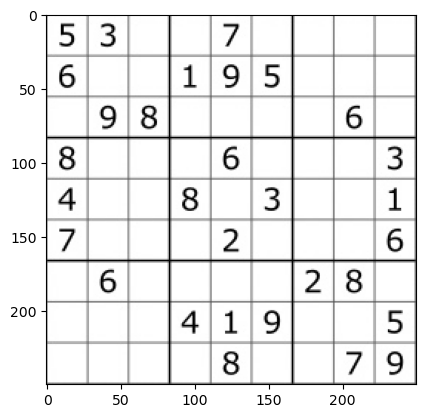

In [37]:
image = cv2.imread ("sudoku.jpeg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# show the grayscale image
plt.imshow(gray, cmap="gray")
plt.show()

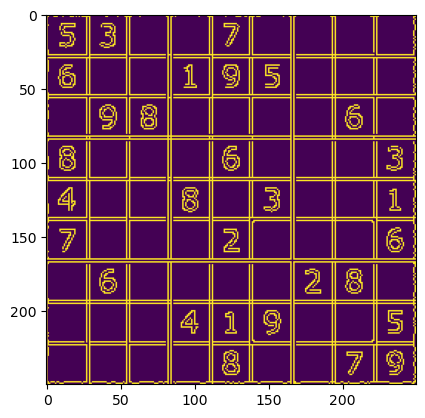

In [38]:
# perform the canny edge detector to detect image edges
edges = cv2.Canny(gray, threshold1=30, threshold2=100)
plt.imshow(edges)

In [39]:
gray

array([[116, 102, 103, ..., 102, 102,  88],
       [102, 255, 253, ..., 255, 255, 133],
       [102, 254, 255, ..., 255, 254, 134],
       ...,
       [103, 255, 255, ..., 255, 255, 133],
       [102, 255, 255, ..., 255, 255, 134],
       [107, 133, 131, ..., 134, 132,  94]], dtype=uint8)

In [40]:
image = cv2.imread("sudoku.jpeg")
# convert to grayscale
grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# perform edge detection
edges = cv2.Canny(grayscale, 30, 100)
# detect lines in the image using hough lines technique
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 60, np.array([]), 50, 5)

lines

array([[[167, 249, 167,   1]],

       [[ 56, 248,  56,   1]],

       [[ 54, 249,  54,   1]],

       [[112, 249, 112,   1]],

       [[  1, 223, 248, 223]],

       [[ 29, 249,  29,   1]],

       [[  1, 167, 249, 167]],

       [[195, 249, 195,   1]],

       [[223, 248, 223,   1]],

       [[165, 249, 165,   0]],

       [[  1, 195, 249, 195]],

       [[  1, 139, 248, 139]],

       [[  1, 110, 248, 110]],

       [[  1,  27, 248,  27]],

       [[ 82, 249,  82,   0]],

       [[139, 248, 139,   1]],

       [[  0,  82, 249,  82]],

       [[  1, 112, 249, 112]],

       [[  1,  56, 248,  56]],

       [[  1, 193, 249, 193]],

       [[  1, 221, 248, 221]],

       [[221, 248, 221,   1]],

       [[110, 248, 110,   1]],

       [[  0, 165, 249, 165]],

       [[  1,  29, 249,  29]],

       [[  1, 137, 249, 137]],

       [[ 30,   0, 218,   0]],

       [[193, 249, 193,   1]],

       [[137, 248, 137,   1]],

       [[ 84, 249,  84,   1]],

       [[ 27, 248,  27,   1]],

       [

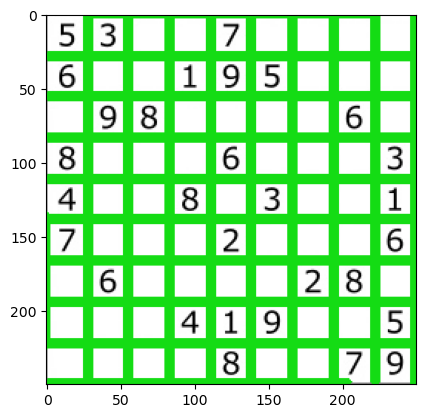

In [41]:
# iterate over the output lines and draw them
for line in lines:
    for x1, y1, x2, y2 in line:
        cv2.line(image, (x1, y1), (x2, y2), (20, 220, 20), 3)

# show the image
plt.imshow(image)
plt.show()



In [42]:
# load the image
img = cv2.imread("sudoku.jpeg")
# convert BGR to RGB to be suitable for showing using matplotlib library
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# make a copy of the original image
cimg = img.copy()
# convert image to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# apply a blur using the median filter
img = cv2.medianBlur(img, 5)


In [43]:
circles = cv2.HoughCircles(image=img, method=cv2.HOUGH_GRADIENT, dp=0.9, minDist=20, param1=110, param2=39, maxRadius=300)
circles

array([[[125.5, 125.5,  41.6],
        [206.5, 206.5,  42.4],
        [ 40.5,  40.5,  41.2],
        [206.5, 127.5,  43.8],
        [126.5,  72.5,  42.7],
        [187.5, 187.5,  23.6],
        [104.5, 104.5,  23.8]]], dtype=float32)

Number of circles detected: 7


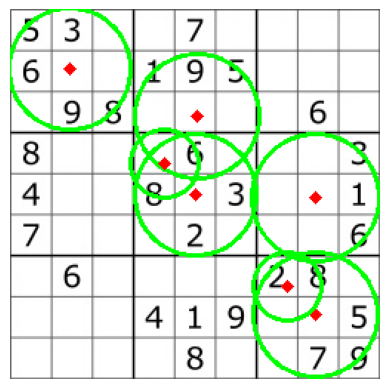

In [44]:
if circles is not None:
    for co, i in enumerate(circles[0, :], start=1):
        x = int(i[0])
        y = int(i[1])
        r = int(i[2])

        # outer circle (green)
        cv2.circle(cimg, (x, y), r, (0, 255, 0), 2)
        # center point (red)
        cv2.circle(cimg, (x, y), 2, (0, 0, 255), 3)

    num_circles = circles.shape[1]
    print("Number of circles detected:", num_circles)

    # BGR -> RGB for matplotlib
    cimg_rgb = cv2.cvtColor(cimg, cv2.COLOR_BGR2RGB)
    plt.imshow(cimg_rgb)
    plt.axis("off")
    plt.show()
else:
    print("No circles were detected.")


In [45]:
cap = cv2.VideoCapture(0)
while True:
    _, image = cap.read()
    # convert to grayscale
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # perform edge detection
    edges = cv2.Canny(grayscale, 30, 100)
    # detect lines in the image using hough lines technique
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 60, np.array([]), 50, 5)
    # iterate over the output lines and draw them
    for line in lines:
        for x1, y1, x2, y2 in line:
            cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.line(edges, (x1, y1), (x2, y2), (255, 0, 0), 3)


KeyboardInterrupt: 

In [ ]:
# show images
    cv2.imshow("image", image)
    cv2.imshow("edges", edges)
    if cv2.waitKey(1) == ord("q"):
        break
cap.release()
cv2.destroyAllWindows()


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_21560/3544988534.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(edges_prewitt_vertical, cmap='gray')


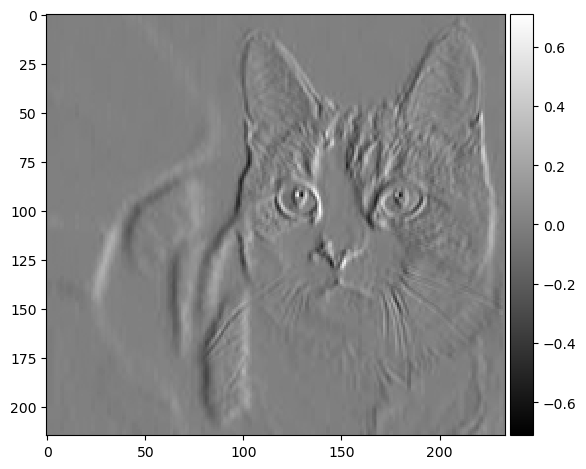

In [49]:
#importing the required libraries
import numpy as np
from skimage.io import imread, imshow
from skimage.filters import prewitt_h,prewitt_v
import matplotlib.pyplot as plt
%matplotlib inline
#reading the image 
image = imread('cat.jpeg',as_gray=True)
#calculating horizontal edges using prewitt kernel
edges_prewitt_horizontal = prewitt_h(image)
#calculating vertical edges using prewitt kernel
edges_prewitt_vertical = prewitt_v(image)
imshow(edges_prewitt_vertical, cmap='gray')
plt.show()
